# Spatial Transcriptomics Workflow Part 2

In [4]:
# Install scanpy, squidpy and matplotlib
!pip install -q scanpy squidpy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.2/199.2 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [5]:
# Import libraries
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [6]:
# Loading prepared AnnData object
adata = sc.read_h5ad("breast_tumor_hvg_2000.h5ad")

In [7]:
adata

AnnData object with n_obs × n_vars = 2516 × 2000
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'spatial'
    obsm: 'spatial'

### Dimensionality Reduction & UMAP Embedding

📉 Compressing 2,000 gene dimensions into Principal Components


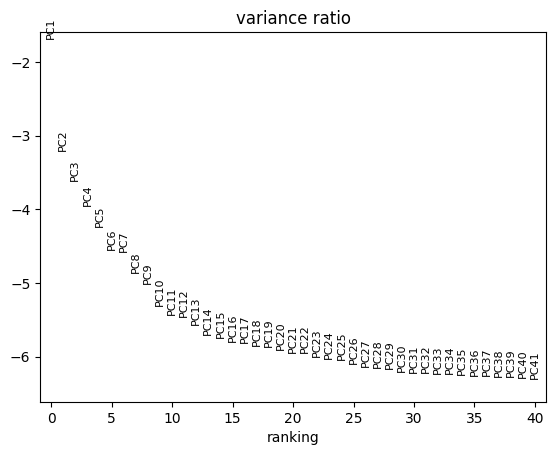

In [8]:
# ==============================================================================
# 1. PRINCIPAL COMPONENT ANALYSIS (PCA)
# ==============================================================================
print("📉 Compressing 2,000 gene dimensions into Principal Components")
sc.tl.pca(
    adata,
    svd_solver='arpack'  # Fast, efficient solver optimized for large sparse matrices
)

# Optional: Plotting the elbow curve to verify 50 components is capturing enough variance
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=40)

# ==============================================================================
# 2. NEIGHBORHOOD GRAPH CONSTRUCTION
# ==============================================================================
sc.pp.neighbors(
    adata,
    n_neighbors=15,      # Size of the local neighborhood context per spot
    n_pcs=30             # Use the top 30 PCA coordinates to evaluate similarity
)

# ==============================================================================
# 3. UMAP EMBEDDING
# ==============================================================================
sc.tl.umap(adata)

### Clustering & Spatial Mapping

In [9]:
!pip install --quiet igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 40.3 MB/s eta 0:00:00


Identified 9 distinct tissue domains.
Projecting calculated clusters back onto anatomy


/tmp/ipykernel_1987/2966121263.py:32: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


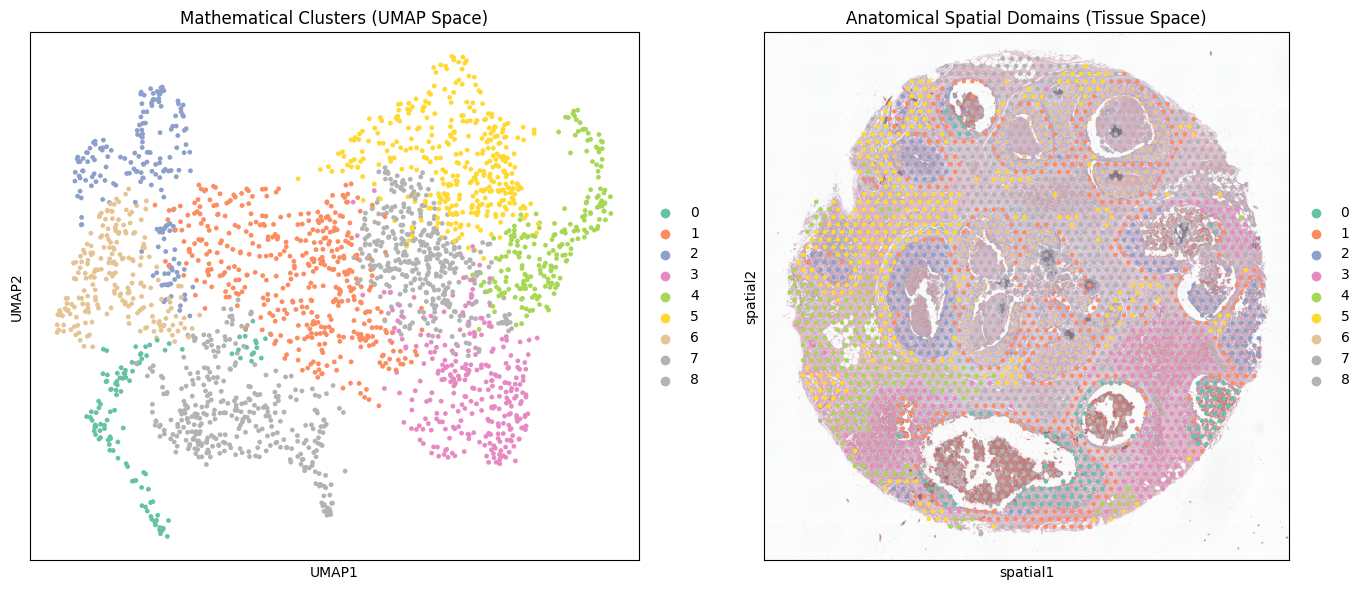

In [10]:
# ==============================================================================
# 1. LEIDEN CLUSTERING
# ==============================================================================
sc.tl.leiden(
    adata,
    resolution=0.5,       # Controls cluster granularity
    flavor="igraph",      # Uses the lightning-fast native backend
    n_iterations=2,       # Standard constraint for stable convergence
    directed=False,       # Required flag when using the igraph backend
    key_added="spatial_domains"
)

print(f"Identified {adata.obs['spatial_domains'].nunique()} distinct tissue domains.")

# ==============================================================================
# 2. VISUALIZE ABSTRACT SPACE VS. PHYSICAL SPACE
# ==============================================================================
print("Projecting calculated clusters back onto anatomy")
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Left Plot: UMAP abstract space
sc.pl.umap(
    adata,
    color="spatial_domains",
    ax=axs[0],
    show=False,
    title="Mathematical Clusters (UMAP Space)",
    palette="Set2"
)

# Right Plot: Real physical tissue coordinates (With Lighter Background)
sc.pl.spatial(
    adata,
    color="spatial_domains",
    ax=axs[1],
    show=False,
    title="Anatomical Spatial Domains (Tissue Space)",
    palette="Set2",
    spot_size=150,
    alpha_img=0.7
)

plt.tight_layout()
plt.show()

In [11]:
print(adata.obs.columns)

Index(['in_tissue', 'array_row', 'array_col', 'n_genes_by_counts',
       'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes',
       'spatial_domains'],
      dtype='object')


### Map Numeric Clusters to cell Types

In [12]:
# Ensure the spatial domains column is treated as a category
adata.obs["spatial_domains"] = adata.obs["spatial_domains"].astype("category")

# Annotations based on marker genes

domain_annotations = {
    "0": "Luminal/Secretory Epithelial",
    "1": "Activated Fibroblast/Myofibroblast",
    "2": "Proliferating Tumor Core",
    "3": "Myeloid/Macrophage Infiltrate",
    "4": "Dense Collagenous Stroma",
    "5": "T-Cell/Lymphoid Zone",
    "6": "Luminal epithelial cells",
    "7": "Remodeling Myofibroblasts",
    "8": "SPP1+ Macrophages"
}
# Rename the categories directly inside the AnnData object
adata.obs["spatial_domains"] = adata.obs["spatial_domains"].cat.rename_categories(domain_annotations)

### Merging Single-spot Transcriptomics with Tissue Histology

🔬 Merging single-spot transcriptomics with tissue histology


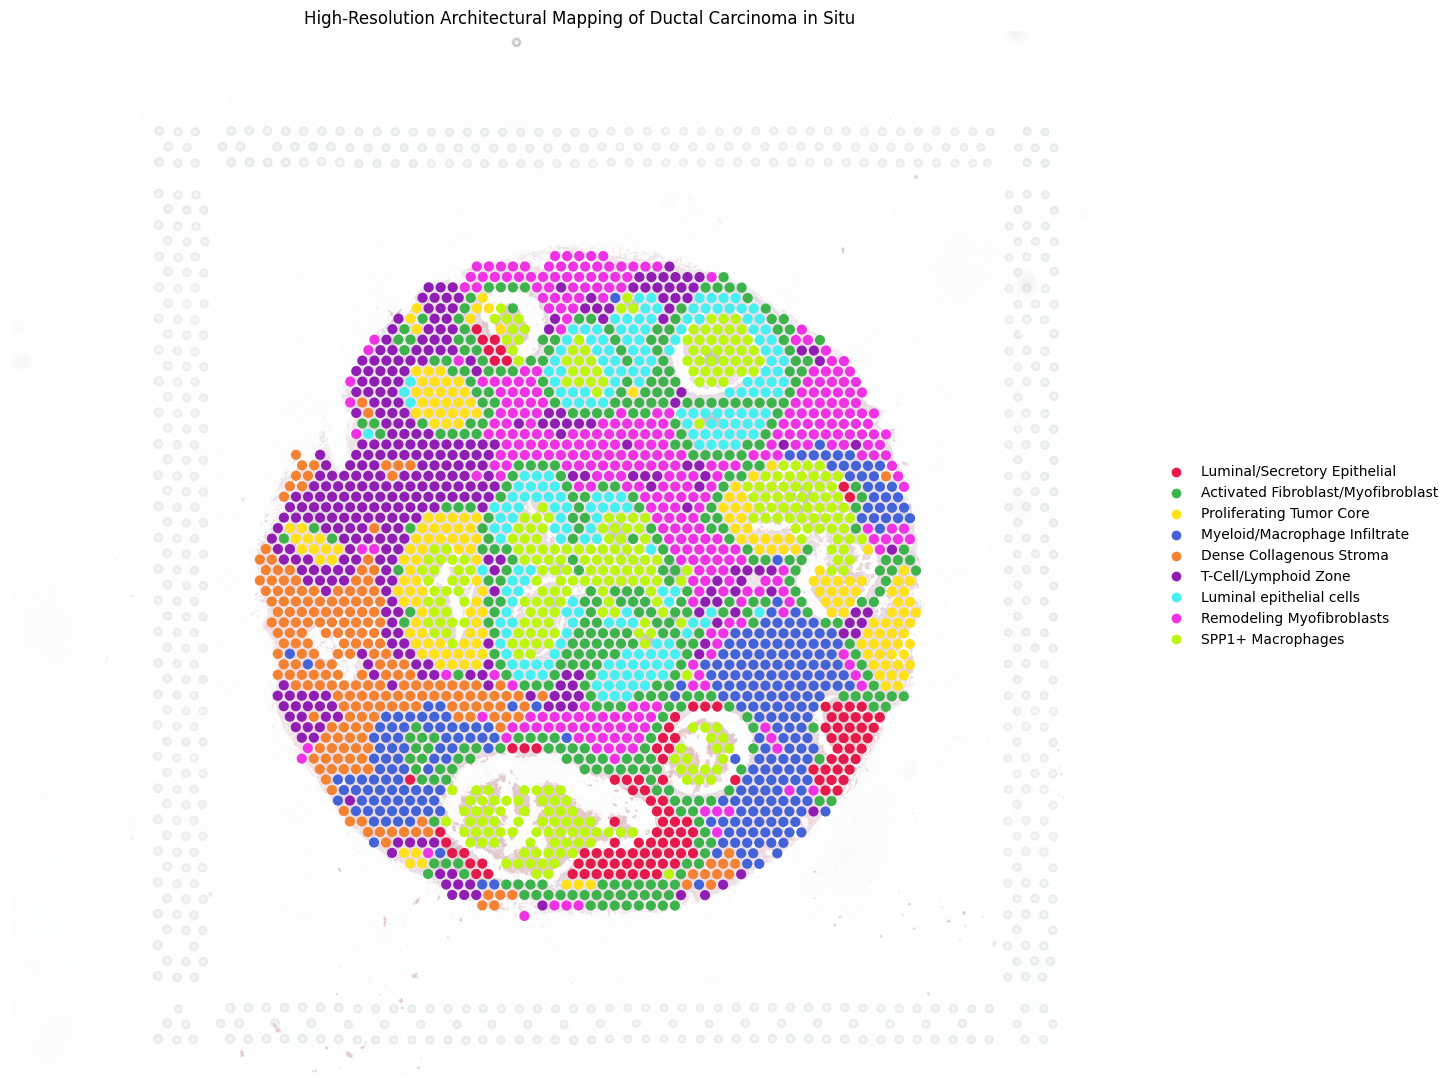

In [13]:
from matplotlib.colors import ListedColormap

# ==============================================================================
# 1. GENERATE THE SQUIDPY-COMPATIBLE COLORMAP
# ==============================================================================
custom_9_colors = [
    "#E6194B", "#3CB44B", "#FFE119", "#4363D8", "#F58231",
    "#911EB4", "#46F0F0", "#F032E6", "#BCF60C"
]
squidpy_palette = ListedColormap(custom_9_colors)

# ==============================================================================
# 2. RENDER HISTOLOGY OVERLAY SCRIPT
# ==============================================================================
print("Merging single-spot transcriptomics with tissue histology")

# Create the figure object explicitly
fig, ax = plt.subplots(figsize=(14, 11))

sq.pl.spatial_scatter(
    adata,
    color="spatial_domains",
    use_raw=False,
    img=True,                      # Renders H&E tissue slice background
    img_alpha=0.3,
    size=1.3,
    palette=squidpy_palette,
    ax=ax,
    title="High-Resolution Architectural Mapping of Ductal Carcinoma in Situ"
)

# Hide the axis lines for a cleaner presentation layout
ax.axis('off')
plt.tight_layout()
plt.show()



In [ ]:
# Save with breast-specific name and strict compression
adata.write_h5ad("breast_cancer_spatial_clustered_complete.h5ad", compression="gzip")
